# 3.1 Project Overview

The Credit Card Creditworthiness Classifier is a multi-class classification system designed to predict the credit score category of a customer based on their financial profile and payment history. It classifies customers into three categories: **Poor**, **Standard**, and **Good** credit. 

The project leverages a 50,000-record real-world dataset and applies a complete ML pipeline including:
- Data cleaning
- Feature engineering
- Encoding
- Outlier handling
- Model comparison between Random Forest and XGBoost


In [97]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv('test.csv')
data = pd.DataFrame(data)give thiss project overview


In [99]:
data.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [100]:
data.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,42502.000000,50000.000000,50000.000000,50000.000000,50000.000000,48965.000000,50000.000000,50000.000000
mean,4182.004291,16.838260,22.921480,68.772640,21.052640,30.080200,32.279581,1491.304305
std,3174.109304,116.396848,129.314804,451.602363,14.860397,196.984121,5.106238,8595.647887
min,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.509652,0.000000
25%,1625.188333,3.000000,4.000000,8.000000,10.000000,4.000000,28.061040,32.222388
50%,3086.305000,6.000000,5.000000,13.000000,18.000000,7.000000,32.280390,74.733349
75%,5934.189094,7.000000,7.000000,20.000000,28.000000,10.000000,36.468591,176.157491
max,15204.633333,1798.000000,1499.000000,5799.000000,67.000000,2593.000000,48.540663,82398.000000


In [101]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44985 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42502 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44296 non-null  object 
 14  Delay_

In [102]:
data = data.drop(['ID','Customer_ID','Month','Name','Age','SSN'],axis=1)

In [103]:
data.head()

,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,9,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,4,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",4,5,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,_______,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,3,1,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [104]:
# Drop Type_of_Loan
data = data.drop(['Type_of_Loan'], axis=1)

In [105]:
data.isna().sum()

Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       7498
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Delay_from_due_date            0
Num_of_Delayed_Payment      3498
Changed_Credit_Limit           0
Num_Credit_Inquiries        1035
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          4470
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     2271
Payment_Behaviour              0
Monthly_Balance              562
dtype: int64

In [106]:
data.dropna(inplace=True)

In [107]:
data.isna().sum()

Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
dtype: int64

In [108]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33267 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Occupation                33267 non-null  object 
 1   Annual_Income             33267 non-null  object 
 2   Monthly_Inhand_Salary     33267 non-null  float64
 3   Num_Bank_Accounts         33267 non-null  int64  
 4   Num_Credit_Card           33267 non-null  int64  
 5   Interest_Rate             33267 non-null  int64  
 6   Num_of_Loan               33267 non-null  object 
 7   Delay_from_due_date       33267 non-null  int64  
 8   Num_of_Delayed_Payment    33267 non-null  object 
 9   Changed_Credit_Limit      33267 non-null  object 
 10  Num_Credit_Inquiries      33267 non-null  float64
 11  Credit_Mix                33267 non-null  object 
 12  Outstanding_Debt          33267 non-null  object 
 13  Credit_Utilization_Ratio  33267 non-null  float64
 14  Credit_Hist

In [109]:
data.duplicated().sum()

np.int64(0)

In [110]:
# Quick overview
print(data.dtypes)

# More detailed with null counts
print(data.info())

# See unique values of suspicious object columns (to spot dirty data)
for col in data.select_dtypes(include='object').columns:
    print(f"\n{col}: {data[col].unique()[:5]}")  # first 5 unique values

Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
dtype: object
<class 'pandas.core.frame.DataFrame'>
Index: 33267 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Occupation                33267 non-null  objec

In [111]:
import re
import numpy as np

# ── 1. Replace junk string values with NaN ──────────────────────────
data['Occupation']        = data['Occupation'].replace('_______', np.nan)
data['Credit_Mix']        = data['Credit_Mix'].replace('_', np.nan)
data['Payment_Behaviour'] = data['Payment_Behaviour'].replace('!@9#%8', np.nan)
data['Payment_of_Min_Amount'] = data['Payment_of_Min_Amount'].replace('NM', np.nan)

# ── 2. Strip non-numeric chars & convert to float ───────────────────
dirty_num_cols = [
    'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
    'Outstanding_Debt', 'Changed_Credit_Limit',
    'Amount_invested_monthly', 'Monthly_Balance'
]
for col in dirty_num_cols:
    data[col] = data[col].astype(str).str.replace(r'[^0-9.\-]', '', regex=True)
    data[col] = pd.to_numeric(data[col], errors='coerce')

# ── 3. Parse Credit_History_Age → total months ──────────────────────
def parse_credit_age(val):
    if pd.isna(val): return np.nan
    years  = re.search(r'(\d+)\s*Year',  str(val))
    months = re.search(r'(\d+)\s*Month', str(val))
    return (int(years.group(1)) * 12 if years else 0) + \
           (int(months.group(1))      if months else 0)

data['Credit_History_Age'] = data['Credit_History_Age'].apply(parse_credit_age)

# ── 4. Clip outliers in Num_of_Loan (valid range: 0–10) ─────────────
data['Num_of_Loan'] = data['Num_of_Loan'].clip(lower=0, upper=10)

# ── 5. Convert categoricals ──────────────────────────────────────────
cat_cols = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
for col in cat_cols:
    data[col] = data[col].astype('category')

In [112]:
print(data.dtypes)
print("\nNull counts:\n", data.isnull().sum())

# Spot check
print(data['Num_of_Loan'].describe())        # should be 0–10
print(data['Credit_History_Age'].head())     # should be integers (months)
print(data['Payment_Behaviour'].unique())    # no more !@9#%8
print(data['Credit_Mix'].unique())           # no more _

Occupation                  category
Annual_Income                float64
Monthly_Inhand_Salary        float64
Num_Bank_Accounts              int64
Num_Credit_Card                int64
Interest_Rate                  int64
Num_of_Loan                    int64
Delay_from_due_date            int64
Num_of_Delayed_Payment         int64
Changed_Credit_Limit         float64
Num_Credit_Inquiries         float64
Credit_Mix                  category
Outstanding_Debt             float64
Credit_Utilization_Ratio     float64
Credit_History_Age             int64
Payment_of_Min_Amount       category
Total_EMI_per_month          float64
Amount_invested_monthly      float64
Payment_Behaviour           category
Monthly_Balance              float64
dtype: object

Null counts:
 Occupation                  2331
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0


In [113]:
# ── 1. Categorical → fill with Mode ─────────────────────────────────
cat_null_cols = ['Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Occupation']

for col in cat_null_cols:
    mode_val = data[col].mode()[0]
    data[col] = data[col].cat.add_categories([mode_val]) \
                if mode_val not in data[col].cat.categories else data[col]
    data[col] = data[col].fillna(mode_val)
    print(f"{col} → filled with mode: '{mode_val}'")

Credit_Mix → filled with mode: 'Standard'
Payment_of_Min_Amount → filled with mode: 'Yes'
Payment_Behaviour → filled with mode: 'Low_spent_Small_value_payments'
Occupation → filled with mode: 'Lawyer'


In [114]:
# ── 2. Numeric → fill with Median ───────────────────────────────────
median_val = data['Changed_Credit_Limit'].median()
data['Changed_Credit_Limit'] = data['Changed_Credit_Limit'].fillna(median_val)
print(f"Changed_Credit_Limit → filled with median: {median_val}")

Changed_Credit_Limit → filled with median: 9.4


In [115]:
print(data.isnull().sum())
# All should be 0

print(f"\nDataset shape: {data.shape}")

Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
dtype: int64

Dataset shape: (33267, 20)


In [116]:
for col in data:
    print(f"\n{col}: {data[col].unique()[:5]}") 
    


Occupation: ['Scientist', 'Lawyer', 'Teacher', 'Engineer', 'Entrepreneur']
Categories (15, object): ['Accountant', 'Architect', 'Developer', 'Doctor', ..., 'Musician', 'Scientist', 'Teacher', 'Writer']

Annual_Income: [  19114.12   34847.84  143162.64   30689.89 4148862.  ]

Monthly_Inhand_Salary: [ 1824.84333333  3037.98666667 12187.22        2612.49083333
  2853.30916667]

Num_Bank_Accounts: [3 2 1 7 4]

Num_Credit_Card: [4 5 1 7 6]

Interest_Rate: [3 6 8 4 5]

Num_of_Loan: [ 4  1  3 10  0]

Delay_from_due_date: [3 6 8 5 0]

Num_of_Delayed_Payment: [7 9 1 3 2]

Changed_Credit_Limit: [11.27 13.27  5.42  7.42  2.1 ]

Num_Credit_Inquiries: [2022.    4.    5.    3.    7.]

Credit_Mix: ['Good', 'Standard', 'Bad']
Categories (3, object): ['Bad', 'Good', 'Standard']

Outstanding_Debt: [ 809.98  605.03 1303.01  632.46  943.86]

Credit_Utilization_Ratio: [35.03040186 33.0531145  25.9268217  30.11660045 33.87516722]

Credit_History_Age: [273 274 327 328 330]

Payment_of_Min_Amount: ['No', 'Ye

In [117]:
from sklearn.preprocessing import LabelEncoder

# ── 1. Label Encode (Ordinal) ────────────────────────────────────────

# Credit_Mix: Bad < Standard < Good
data['Credit_Mix'] = data['Credit_Mix'].map({'Bad': 0, 'Standard': 1, 'Good': 2})

# Payment_of_Min_Amount: No=0, Yes=1
data['Payment_of_Min_Amount'] = data['Payment_of_Min_Amount'].map({'No': 0, 'Yes': 1})


# ── 2. One-Hot Encode (Nominal) ──────────────────────────────────────
data = pd.get_dummies(data, columns=['Occupation', 'Payment_Behaviour'], drop_first=False)
# drop_first=False keeps all categories for interpretability

In [118]:
print(data.shape)         # columns increase after OHE
print(data.dtypes)
print(data['Credit_Mix'].unique())             # should be 0, 1, 2
print(data['Payment_of_Min_Amount'].unique())  # should be 0, 1

(33267, 39)
Annual_Income                                          float64
Monthly_Inhand_Salary                                  float64
Num_Bank_Accounts                                        int64
Num_Credit_Card                                          int64
Interest_Rate                                            int64
Num_of_Loan                                              int64
Delay_from_due_date                                      int64
Num_of_Delayed_Payment                                   int64
Changed_Credit_Limit                                   float64
Num_Credit_Inquiries                                   float64
Credit_Mix                                            category
Outstanding_Debt                                       float64
Credit_Utilization_Ratio                               float64
Credit_History_Age                                       int64
Payment_of_Min_Amount                                 category
Total_EMI_per_month                        

In [119]:
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

In [120]:
for col in data:
    print(f"\n{col}: {data[col].unique()[:5]}") 
    


Annual_Income: [  19114.12   34847.84  143162.64   30689.89 4148862.  ]

Monthly_Inhand_Salary: [ 1824.84333333  3037.98666667 12187.22        2612.49083333
  2853.30916667]

Num_Bank_Accounts: [3 2 1 7 4]

Num_Credit_Card: [4 5 1 7 6]

Interest_Rate: [3 6 8 4 5]

Num_of_Loan: [ 4  1  3 10  0]

Delay_from_due_date: [3 6 8 5 0]

Num_of_Delayed_Payment: [7 9 1 3 2]

Changed_Credit_Limit: [11.27 13.27  5.42  7.42  2.1 ]

Num_Credit_Inquiries: [2022.    4.    5.    3.    7.]

Credit_Mix: [2, 1, 0]
Categories (3, int64): [0, 2, 1]

Outstanding_Debt: [ 809.98  605.03 1303.01  632.46  943.86]

Credit_Utilization_Ratio: [35.03040186 33.0531145  25.9268217  30.11660045 33.87516722]

Credit_History_Age: [273 274 327 328 330]

Payment_of_Min_Amount: [0, 1]
Categories (2, int64): [0, 1]

Total_EMI_per_month: [ 49.57494921  18.81621457 246.99231945  16.41545166   0.        ]

Amount_invested_monthly: [236.64268203  21.46538026  39.68401842 251.62736875 153.53448761]

Monthly_Balance: [186.26670209

In [121]:
data.head()

,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,...,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,19114.12,1824.843333,3,4,3,4,3,7,11.27,2022.0,...,0,1,0,0,0,0,0,0,0,1
1,19114.12,1824.843333,3,4,3,4,3,9,13.27,4.0,...,0,1,0,0,0,1,0,0,0,0
4,34847.84,3037.986667,2,4,6,1,3,1,5.42,5.0,...,0,0,0,0,1,0,0,0,0,0
5,34847.84,3037.986667,2,4,6,1,3,3,5.42,5.0,...,0,0,1,0,0,0,0,1,0,0
7,34847.84,3037.986667,2,4,6,1,3,2,7.42,5.0,...,0,0,1,0,0,0,0,0,0,1


In [122]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33267 entries, 0 to 49999
Data columns (total 39 columns):
 #   Column                                              Non-Null Count  Dtype   
---  ------                                              --------------  -----   
 0   Annual_Income                                       33267 non-null  float64 
 1   Monthly_Inhand_Salary                               33267 non-null  float64 
 2   Num_Bank_Accounts                                   33267 non-null  int64   
 3   Num_Credit_Card                                     33267 non-null  int64   
 4   Interest_Rate                                       33267 non-null  int64   
 5   Num_of_Loan                                         33267 non-null  int64   
 6   Delay_from_due_date                                 33267 non-null  int64   
 7   Num_of_Delayed_Payment                              33267 non-null  int64   
 8   Changed_Credit_Limit                                33267 non-null  flo

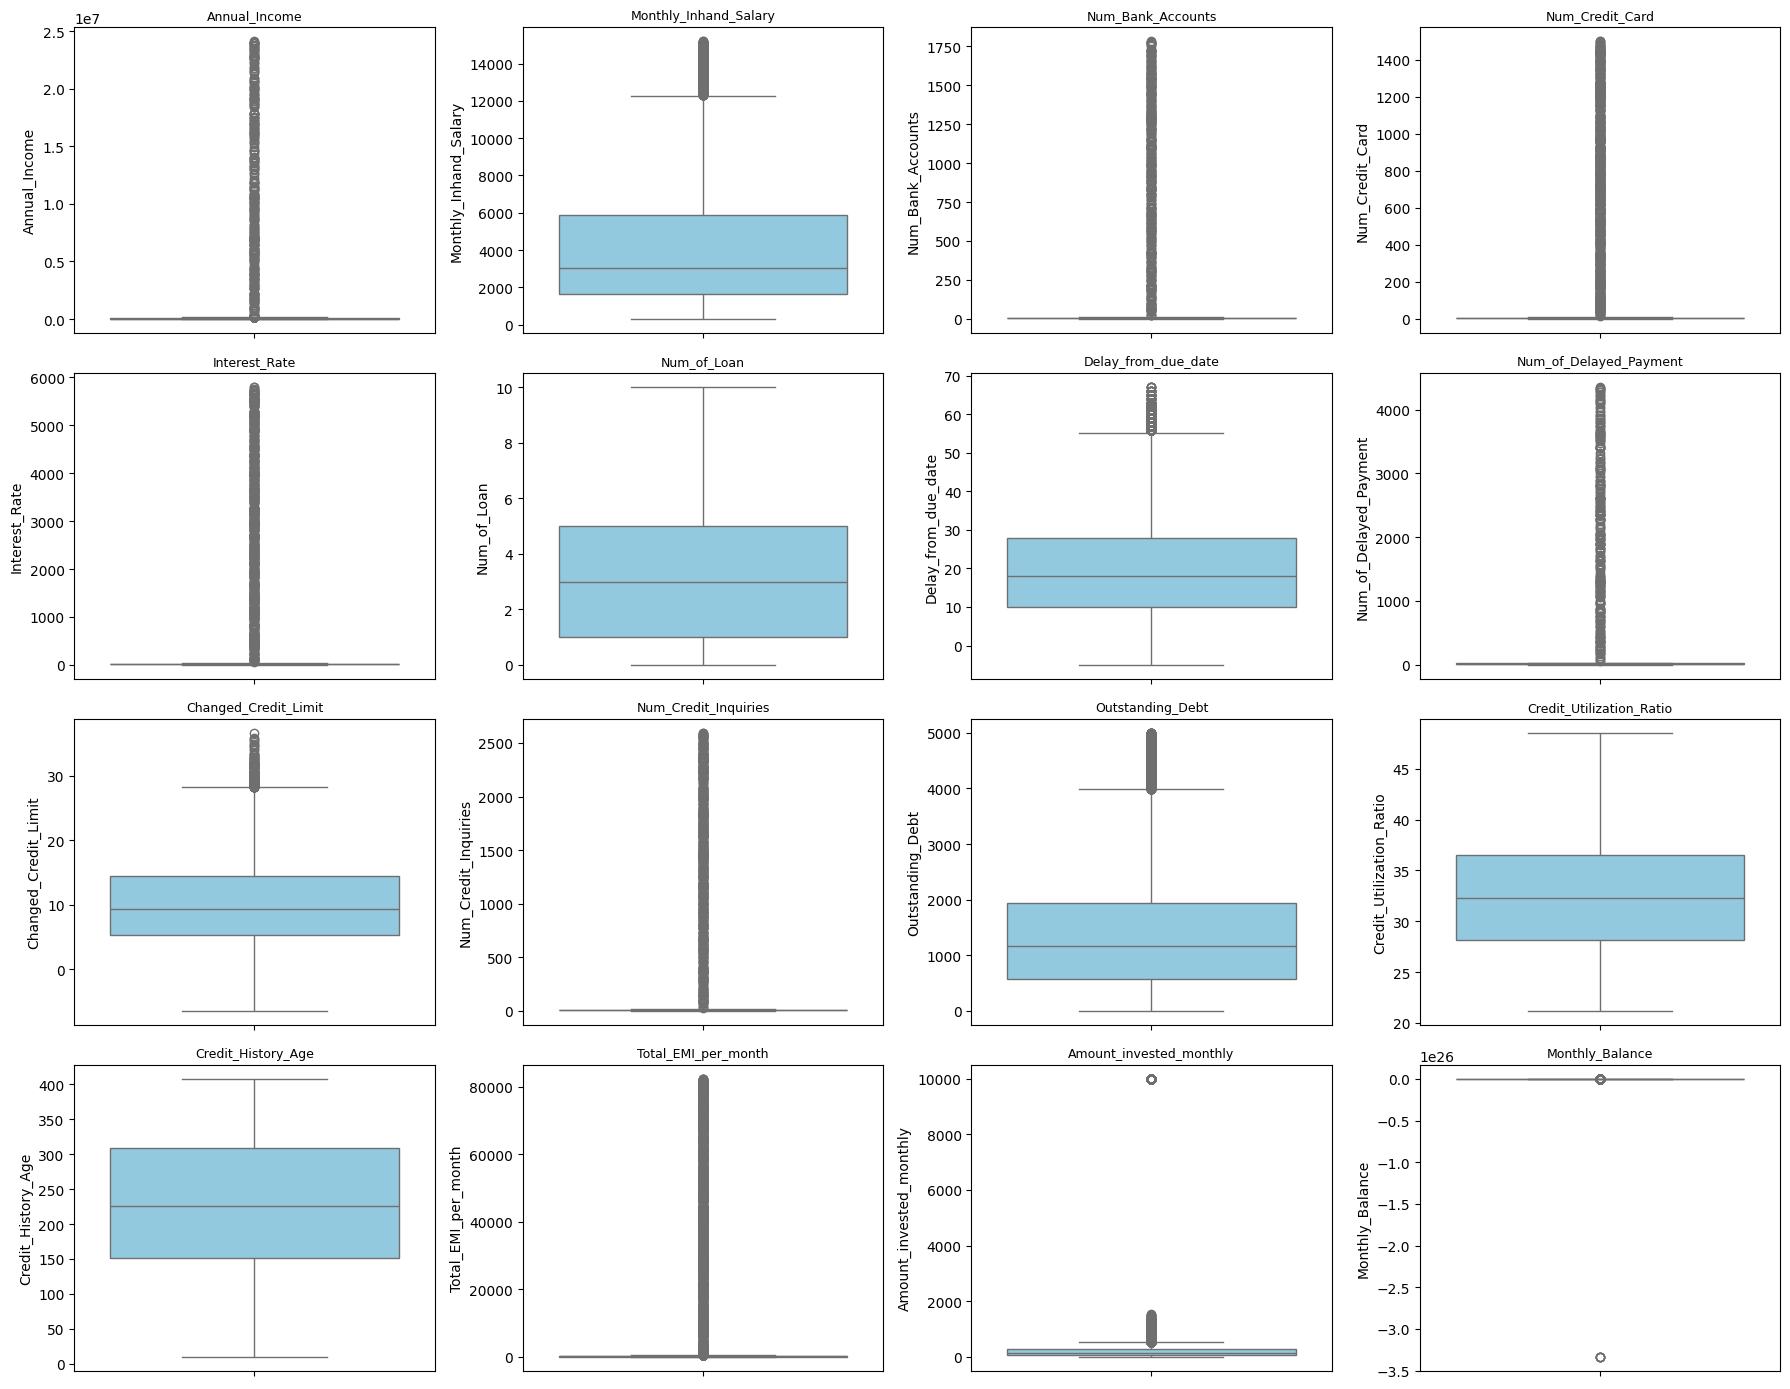

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [
    'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
    'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
    'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
    'Monthly_Balance'
]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=data[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

In [124]:
def detect_outliers(df, cols):
    summary = []
    for col in cols:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
        pct   = round(n_out / len(df) * 100, 2)
        summary.append({
            'Column': col, 'Lower_Bound': round(lower, 2),
            'Upper_Bound': round(upper, 2),
            'Outlier_Count': n_out, 'Outlier_%': pct
        })
    return pd.DataFrame(summary).sort_values('Outlier_%', ascending=False)

outlier_report = detect_outliers(data, num_cols)
print(outlier_report)

                      Column  Lower_Bound  Upper_Bound  Outlier_Count  \
14   Amount_invested_monthly      -201.81       532.95           3378   
13       Total_EMI_per_month      -179.72       383.59           2622   
15           Monthly_Balance       -30.24       771.75           2551   
10          Outstanding_Debt     -1481.88      3986.17           1778   
6        Delay_from_due_date       -17.00        55.00           1323   
0              Annual_Income    -60022.11    151469.10            940   
3            Num_Credit_Card        -0.50        11.50            750   
1      Monthly_Inhand_Salary     -4790.26     12294.30            698   
4              Interest_Rate       -10.00        38.00            663   
9       Num_Credit_Inquiries        -5.00        19.00            594   
8       Changed_Credit_Limit        -8.34        28.22            443   
2          Num_Bank_Accounts        -3.00        13.00            438   
7     Num_of_Delayed_Payment        -4.50        31

In [125]:
# ── Columns already know have extreme values ─────────────────────────

# Based on what we saw earlier:
# Num_Credit_Inquiries had 2022.0 (clearly wrong)
# Annual_Income had 4148862 (possible but extreme)
# Num_Bank_Accounts, Num_Credit_Card → real-world max ~10–15

# Strategy: Cap with IQR Winsorization (clip to bounds)
def cap_outliers_iqr(df, cols):
    for col in cols:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = df[(df[col] < lower) | (df[col] > upper)].shape[0]
        df[col] = df[col].clip(lower=lower, upper=upper)
        print(f"{col}: {before} outliers capped → [{round(lower,2)}, {round(upper,2)}]")
    return df

# Columns to Winsorize
winsorize_cols = [
    'Annual_Income', 'Monthly_Inhand_Salary',
    'Num_Bank_Accounts', 'Num_Credit_Card',
    'Num_of_Delayed_Payment', 'Num_Credit_Inquiries',
    'Outstanding_Debt', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance'
]

data = cap_outliers_iqr(data, winsorize_cols)

Annual_Income: 940 outliers capped → [-60022.11, 151469.1]
Monthly_Inhand_Salary: 698 outliers capped → [-4790.26, 12294.3]
Num_Bank_Accounts: 438 outliers capped → [-3.0, 13.0]
Num_Credit_Card: 750 outliers capped → [-0.5, 11.5]
Num_of_Delayed_Payment: 287 outliers capped → [-4.5, 31.5]
Num_Credit_Inquiries: 594 outliers capped → [-5.0, 19.0]
Outstanding_Debt: 1778 outliers capped → [-1481.88, 3986.17]
Total_EMI_per_month: 2622 outliers capped → [-179.72, 383.59]
Amount_invested_monthly: 3378 outliers capped → [-201.81, 532.95]
Monthly_Balance: 2551 outliers capped → [-30.24, 771.75]


In [126]:
# These have known real-world valid ranges → hard cap instead of IQR

# Interest rate: typically 1–36%
data['Interest_Rate'] = data['Interest_Rate'].clip(1, 36)

# Delay from due: 0–60 days is realistic
data['Delay_from_due_date'] = data['Delay_from_due_date'].clip(0, 60)

# Num of loans: already clipped to 0–10 earlier ✅

# Credit Utilization: 0–100%
data['Credit_Utilization_Ratio'] = data['Credit_Utilization_Ratio'].clip(0, 100)

# Changed Credit Limit: -50% to +100% realistic
data['Changed_Credit_Limit'] = data['Changed_Credit_Limit'].clip(-50, 100)

print("Hard caps applied ✅")

Hard caps applied ✅


                      Column  Lower_Bound  Upper_Bound  Outlier_Count  \
6        Delay_from_due_date       -17.00        55.00           1323   
8       Changed_Credit_Limit        -8.34        28.22            443   
2          Num_Bank_Accounts        -3.00        13.00              0   
0              Annual_Income    -60022.11    151469.10              0   
3            Num_Credit_Card        -0.50        11.50              0   
4              Interest_Rate       -10.00        38.00              0   
5                Num_of_Loan        -5.00        11.00              0   
1      Monthly_Inhand_Salary     -4790.26     12294.30              0   
7     Num_of_Delayed_Payment        -4.50        31.50              0   
9       Num_Credit_Inquiries        -5.00        19.00              0   
10          Outstanding_Debt     -1481.88      3986.17              0   
11  Credit_Utilization_Ratio        15.60        49.04              0   
12        Credit_History_Age       -86.00       546

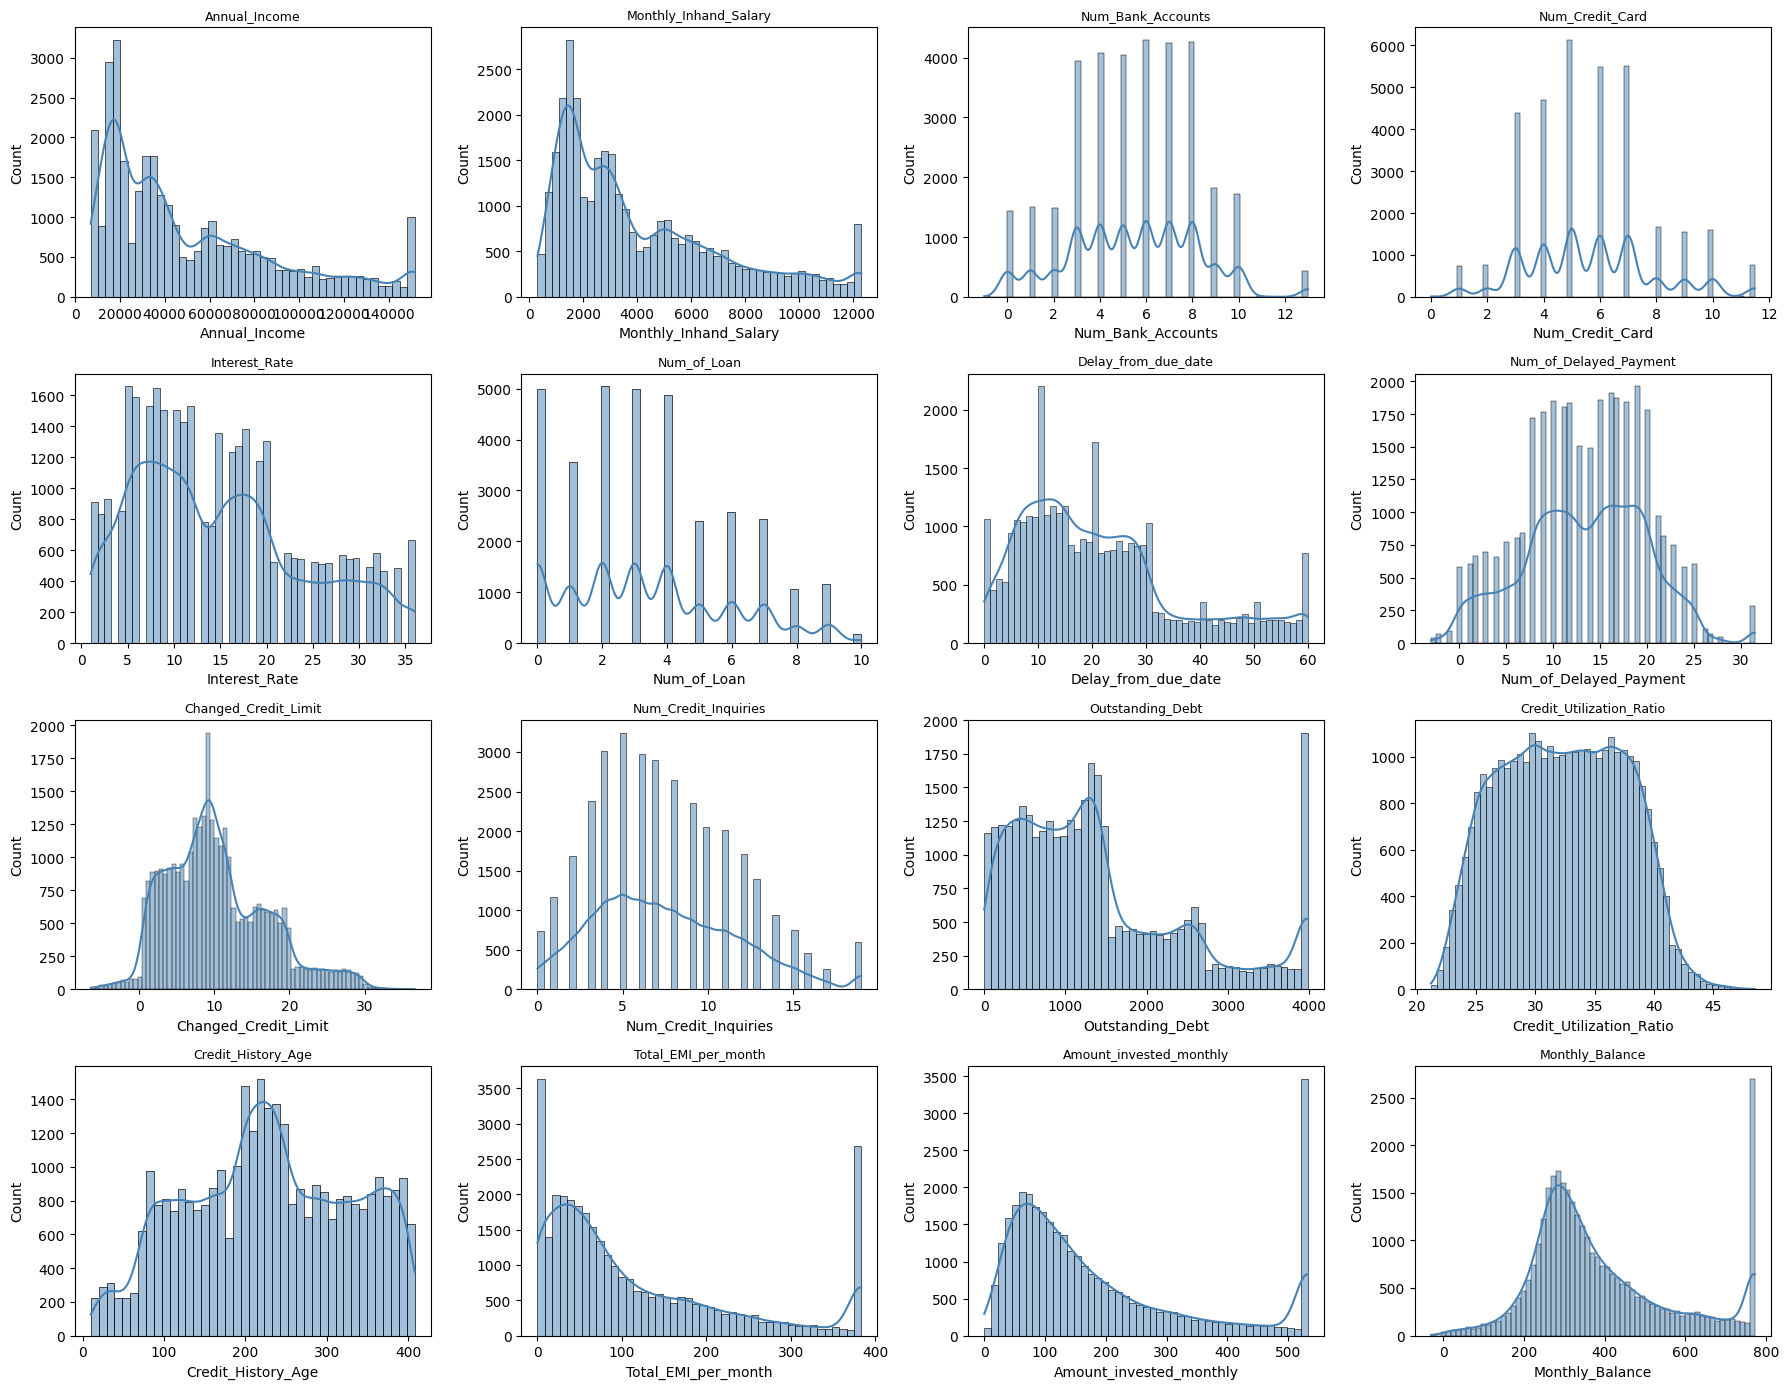

In [127]:
# Re-run outlier report after capping
outlier_report_after = detect_outliers(data, num_cols)
print(outlier_report_after)

# Distribution check
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(data[col], ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

In [128]:
data.head()

,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,...,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,19114.12,1824.843333,3,4.0,3,4,3,7.0,11.27,19.0,...,0,1,0,0,0,0,0,0,0,1
1,19114.12,1824.843333,3,4.0,3,4,3,9.0,13.27,4.0,...,0,1,0,0,0,1,0,0,0,0
4,34847.84,3037.986667,2,4.0,6,1,3,1.0,5.42,5.0,...,0,0,0,0,1,0,0,0,0,0
5,34847.84,3037.986667,2,4.0,6,1,3,3.0,5.42,5.0,...,0,0,1,0,0,0,0,1,0,0
7,34847.84,3037.986667,2,4.0,6,1,3,2.0,7.42,5.0,...,0,0,1,0,0,0,0,0,0,1


In [145]:
data.Credit_Mix.unique()

[2, 1, 0]
Categories (3, int64): [0, 2, 1]

In [132]:
X = data.drop('Credit_Mix',axis=1)
y = data['Credit_Mix']

In [136]:
X.columns

Index(['Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Monthly_Balance', 'Occupation_Accountant',
       'Occupation_Architect', 'Occupation_Developer', 'Occupation_Doctor',
       'Occupation_Engineer', 'Occupation_Entrepreneur',
       'Occupation_Journalist', 'Occupation_Lawyer', 'Occupation_Manager',
       'Occupation_Mechanic', 'Occupation_Media_Manager',
       'Occupation_Musician', 'Occupation_Scientist', 'Occupation_Teacher',
       'Occupation_Writer',
       'Payment_Behaviour_High_spent_Large_value_payments',
       'Payment_Behaviour_High_spent_Medium_value_payments',
       'Payment_Behaviour_High_spent_Small_value_payments',
       

In [138]:
y

0        2
1        2
4        2
5        2
7        1
        ..
49992    0
49993    0
49994    0
49997    2
49999    1
Name: Credit_Mix, Length: 33267, dtype: category
Categories (3, int64): [0, 2, 1]

In [139]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [140]:
X_train.shape

(26613, 38)

In [142]:
y_train.shape

(26613,)

In [146]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



# ── 3. Load & Fit Random Forest ──────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=None,        # let trees grow fully
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

rf.fit(X_train, y_train)
print("\nModel trained ✅")

# ── 4. Predict ───────────────────────────────────────────────────────
y_pred = rf.predict(X_test)

# ── 5. Evaluate ──────────────────────────────────────────────────────
print(f"\nAccuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Model trained ✅

Accuracy: 85.39%

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.94      0.86      1296
           1       0.92      0.81      0.86      3728
           2       0.78      0.89      0.83      1630

    accuracy                           0.85      6654
   macro avg       0.83      0.88      0.85      6654
weighted avg       0.86      0.85      0.85      6654

Confusion Matrix:
[[1214   82    0]
 [ 305 3021  402]
 [   0  183 1447]]


In [149]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# ── 1. Encode target (XGBoost needs 0,1,2 not text) ─────────────────
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print(f"Classes: {le.classes_}")

# ── 2. Fix category dtypes ───────────────────────────────────────────
cat_cols = X_train.select_dtypes(include='category').columns
X_train[cat_cols] = X_train[cat_cols].astype(int)
X_test[cat_cols]  = X_test[cat_cols].astype(int)
print(f"Fixed category cols: {cat_cols.tolist()}")

# ── 3. Load & Fit XGBoost ────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
)

xgb.fit(
    X_train, y_train_enc,
    eval_set=[(X_test, y_test_enc)],
    verbose=50
)

print("\nXGBoost trained ✅")

# ── 4. Predict ───────────────────────────────────────────────────────
y_pred_xgb = xgb.predict(X_test)

# ── 5. Evaluate ──────────────────────────────────────────────────────
print(f"\nRandom Forest Accuracy: 85.39%")
print(f"XGBoost Accuracy:       {accuracy_score(y_test_enc, y_pred_xgb) * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_xgb,
      target_names=['Poor', 'Standard', 'Good']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_enc, y_pred_xgb))

Classes: [0 1 2]
Fixed category cols: []
[0]	validation_0-mlogloss:0.91294
[50]	validation_0-mlogloss:0.36792
[100]	validation_0-mlogloss:0.35727
[150]	validation_0-mlogloss:0.35615
[199]	validation_0-mlogloss:0.35497

XGBoost trained ✅

Random Forest Accuracy: 85.39%
XGBoost Accuracy:       84.79%

Classification Report:
              precision    recall  f1-score   support

        Poor       0.79      0.92      0.85      1296
    Standard       0.92      0.80      0.86      3728
        Good       0.78      0.90      0.83      1630

    accuracy                           0.85      6654
   macro avg       0.83      0.87      0.85      6654
weighted avg       0.86      0.85      0.85      6654


Confusion Matrix:
[[1196  100    0]
 [ 327 2986  415]
 [   0  170 1460]]
